In [1]:
import os
import sys
sys.path.append('../src')  # so we can import from src/

import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from dataset import load_captions, Vocabulary

IMAGES_DIR    = '../flickrdataset/Images'
CAPTIONS_FILE = '../flickrdataset/captions.txt'

In [2]:
with open(CAPTIONS_FILE, 'r') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 5:
            break

'image,caption\n'
'1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .\n'
'1000268201_693b08cb0e.jpg,A girl going into a wooden building .\n'
'1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .\n'
'1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .\n'
'1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .\n'
'1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting\n'


In [4]:
captions_dict = load_captions(CAPTIONS_FILE)

num_images   = len(captions_dict)
num_captions = sum(len(v) for v in captions_dict.values())

print(f'Images   : {num_images}')
print(f'Captions : {num_captions}')

if num_images == 0:
    print("captions_dict is empty — check your CAPTIONS_FILE path and load_captions function")
else:
    print(f'Captions per image: {num_captions // num_images}')

Images   : 8091
Captions : 40455
Captions per image: 5


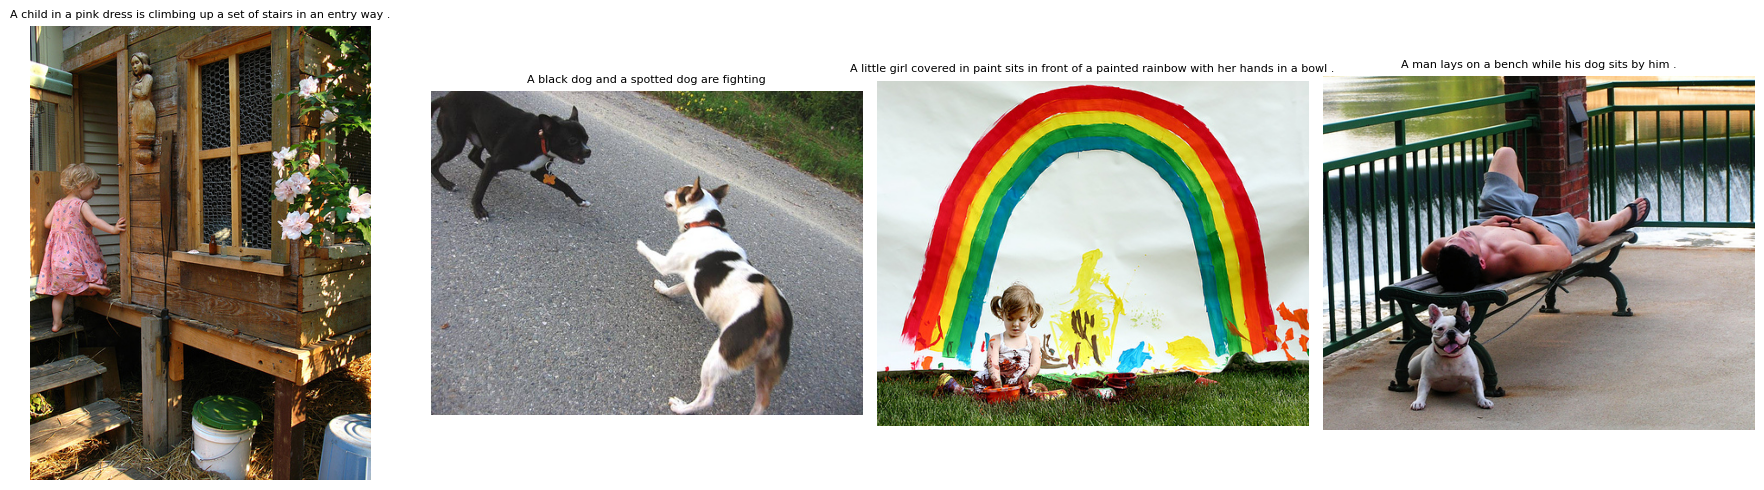

In [5]:
sample_images = list(captions_dict.keys())[:4]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, image_name in zip(axes, sample_images):
    image_path = os.path.join(IMAGES_DIR, image_name)
    image = Image.open(image_path)
    # show just the first caption under each image
    caption = captions_dict[image_name][0]
    ax.imshow(image)
    ax.set_title(caption, fontsize=8, wrap=True)
    ax.axis('off')

plt.tight_layout()
plt.show()

Shortest caption : 1 words
Longest caption  : 38 words
Average length   : 11.8 words


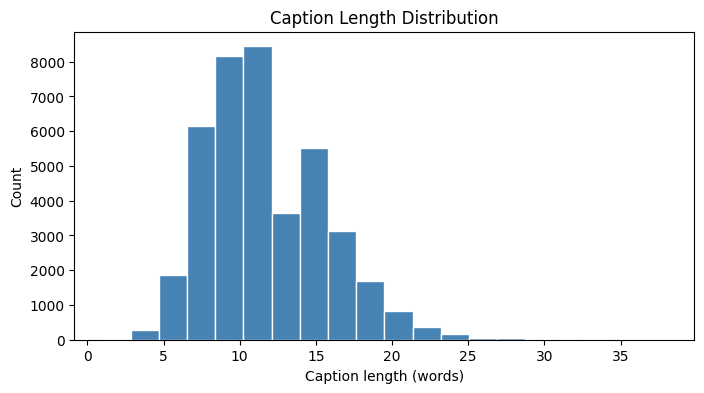

In [6]:
all_captions = [c for captions in captions_dict.values() for c in captions]
lengths = [len(c.split()) for c in all_captions]

print(f'Shortest caption : {min(lengths)} words')
print(f'Longest caption  : {max(lengths)} words')
print(f'Average length   : {sum(lengths)/len(lengths):.1f} words')

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Caption length (words)')
plt.ylabel('Count')
plt.title('Caption Length Distribution')
plt.show()

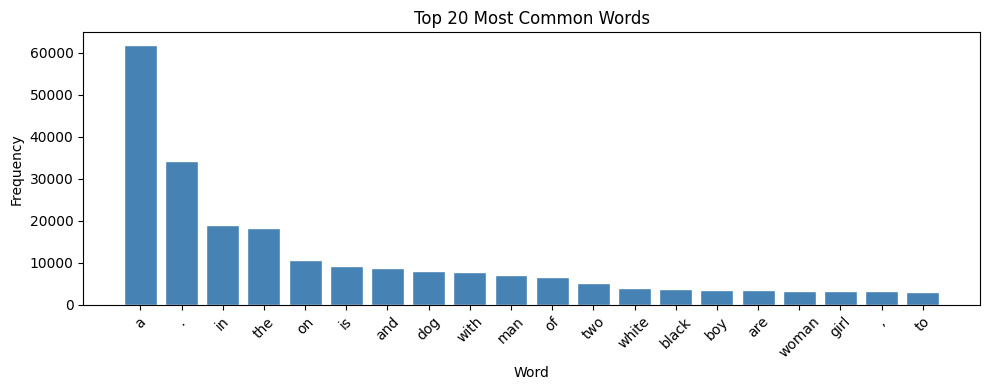

In [7]:
word_counter = Counter()
for caption in all_captions:
    word_counter.update(caption.lower().split())

top_20 = word_counter.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(10, 4))
plt.bar(words, counts, color='steelblue', edgecolor='white')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Top 20 Most Common Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
vocab = Vocabulary()
vocab.build_vocab(all_captions)

print(f'Total unique words : {len(vocab)}')
print()
print('Sample word → index mappings:')
for word in ['a', 'dog', 'running', 'the', '<START>', '<END>', '<UNK>']:
    idx = vocab.word2idx.get(word, '(not in vocab)')
    print(f'  {word:10} → {idx}')

Total unique words : 9184

Sample word → index mappings:
  a          → 4
  dog        → 31
  running    → 121
  the        → 26
  <START>    → 1
  <END>      → 2
  <UNK>      → 3


In [9]:
sample_caption = all_captions[0]
indices = vocab.caption_to_indices(sample_caption)

print(f'Caption : {sample_caption}')
print(f'Indices : {indices}')
print()
# decode back to words to verify
decoded = [vocab.idx2word[i] for i in indices]
print(f'Decoded : {decoded}')

Caption : A child in a pink dress is climbing up a set of stairs in an entry way .
Indices : [1, 4, 5, 6, 4, 7, 8, 9, 10, 11, 4, 12, 13, 14, 6, 15, 16, 17, 18, 2]

Decoded : ['<START>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way', '.', '<END>']
